Train/Validation/Test: 390 12 12

B0 65.287
S0 115.155
C16 64.542
C64 78.53
C64_32 71.175
BS4 69.526
BS16 79.522
BS32 62.646
LOSS_MAE 63.953
LOSS_HUBER 67.961
LR_HIGH 87.114
LR_LOW 71.93
LR_SCHED 70.74
RELU 59.232
CLIP 61.703
BN 264.584
L2 68.538
ACT_L1 61.974
MAXNORM 62.628
DROP 73.824
NOISE 60.791
ES0 73.343
ES1 57.457
P0 63.846
Selected final model: F1_ES


                 Model      MAE     RMSE      R2      SMAPE
0        Baseline LSTM  42.5159  63.0025  0.8601  56.719601
1  Selected Final LSTM  34.2437  47.8793  0.9192  53.013100


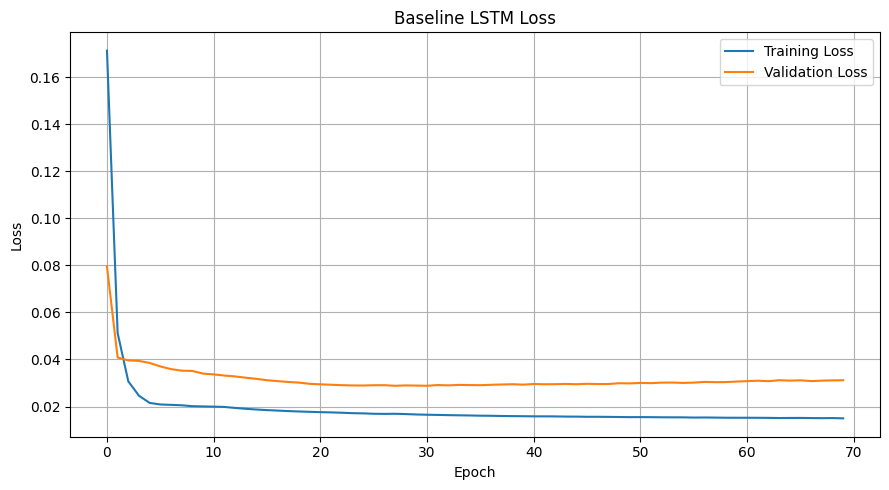

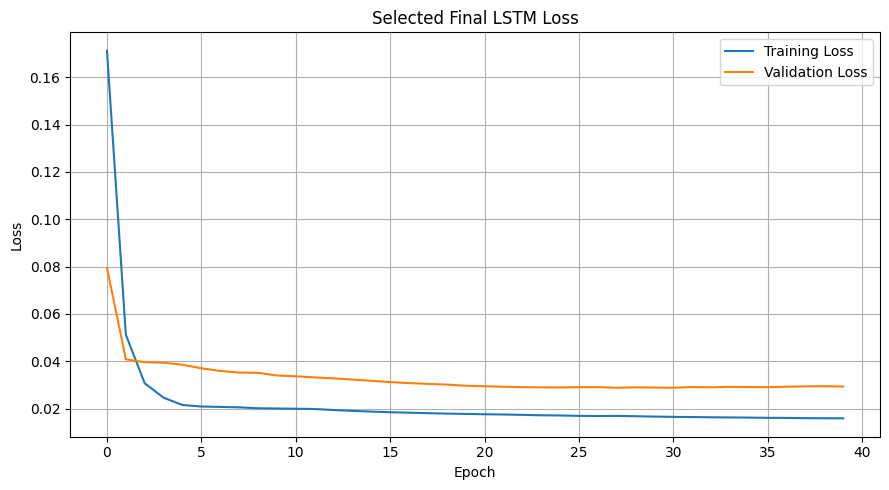

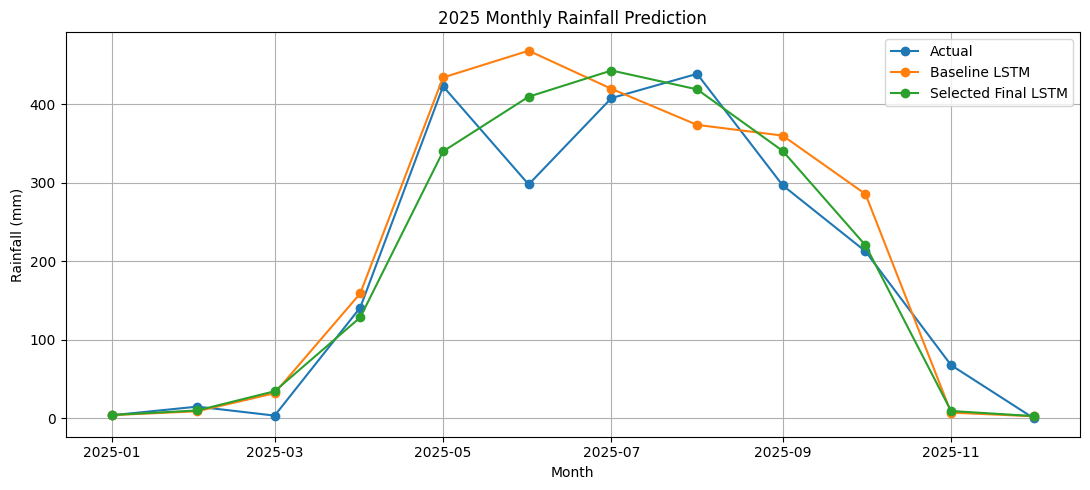

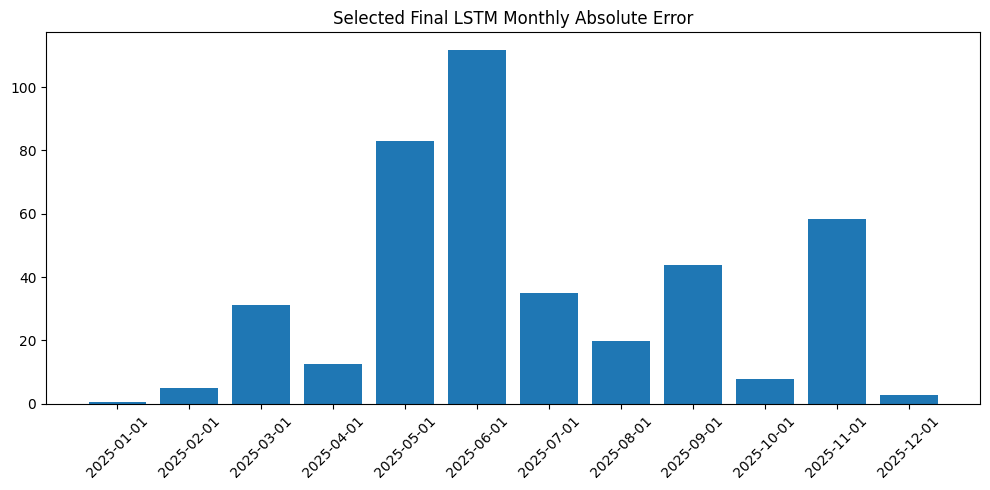

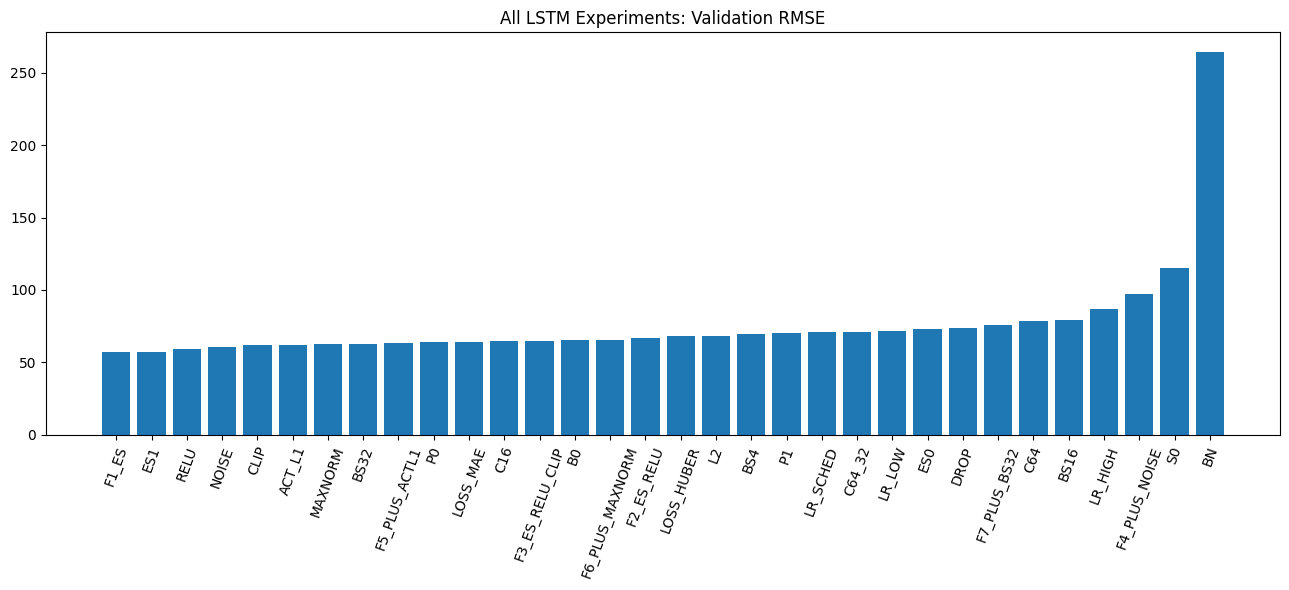

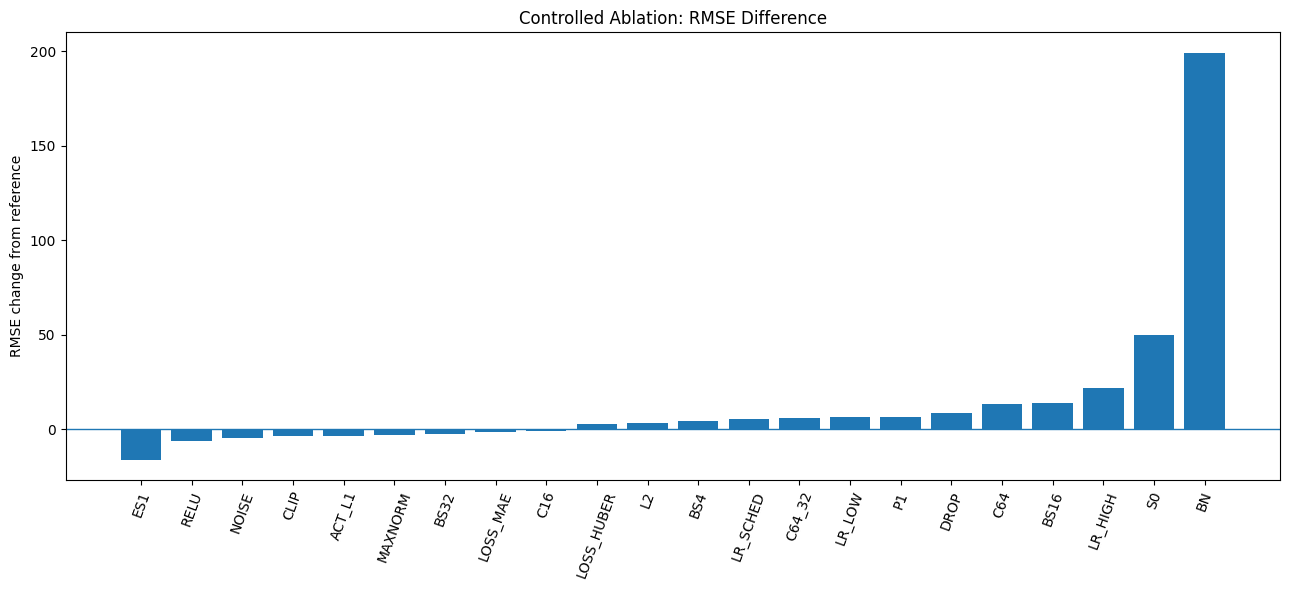

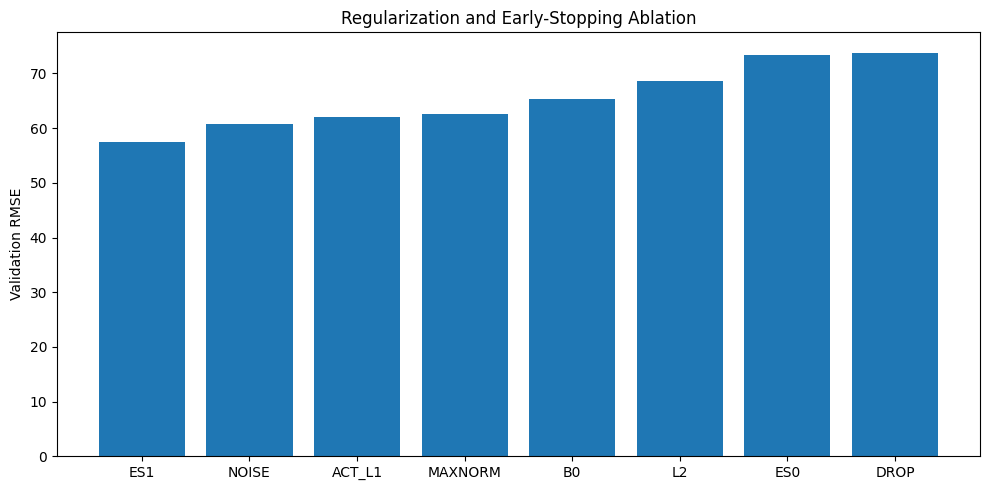

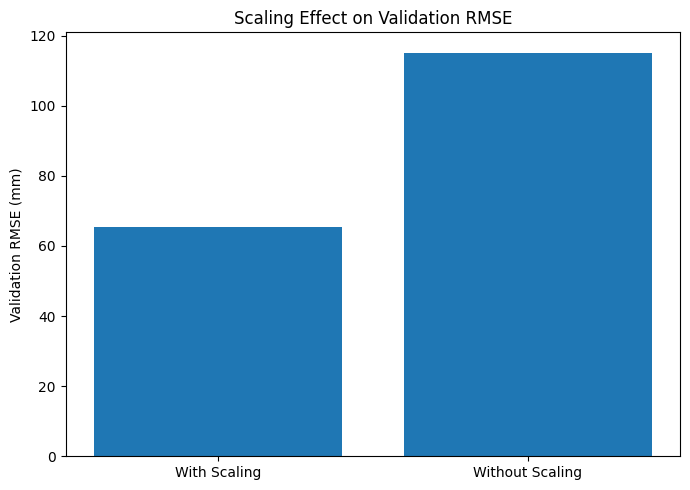

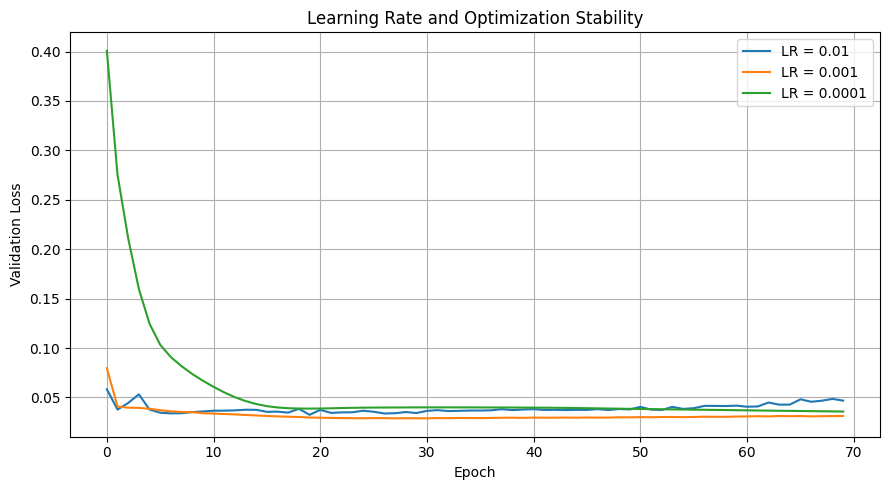

DONE. Files saved in: advanced_lstm_outputs


In [1]:
# 1. Imports
import os, sys, time, random, warnings, platform
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn, tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, BatchNormalization, GaussianNoise, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l1, l2
from tensorflow.keras.constraints import MaxNorm

# 2. Reproducibility, environment, paths
SEED = 7
np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)
OUT = "advanced_lstm_outputs"; os.makedirs(OUT, exist_ok=True)
env = {"Python":sys.version.split()[0], "Platform":platform.platform(), "TensorFlow":tf.__version__,
       "NumPy":np.__version__, "Pandas":pd.__version__, "Scikit-learn":sklearn.__version__}
pd.Series(env).to_csv(os.path.join(OUT, "environment_details.csv"), header=["Version"])
paths = ["G:/Z. Khulna 2026 data/Bogra_Daily_Weather Data.csv"]
DATA_PATH = next((p for p in paths if os.path.exists(p)), None)
if DATA_PATH is None: raise FileNotFoundError("Place Bogra_Daily_Weather Data.csv beside the script.")
raw = pd.read_csv(DATA_PATH, skiprows=13); raw.columns = raw.columns.str.strip()

# 3. Cleaning and monthly aggregation
df = raw.rename(columns={"YEAR":"year","DOY":"doy","ALLSKY_SFC_SW_DWN":"solar_radiation",
    "RH2M":"humidity","T2M_MIN":"temp_min","T2M_MAX":"temp_max","PRECTOTCORR":"rainfall"}).copy()
for c in df.columns: df[c] = pd.to_numeric(df[c], errors="coerce")
df = df.replace(-999, np.nan).dropna(subset=["year","doy"])
df["date"] = pd.to_datetime(df["year"].astype(int).astype(str), format="%Y") + pd.to_timedelta(df["doy"]-1, unit="D")
df = df.sort_values("date").reset_index(drop=True)
weather = ["solar_radiation","humidity","temp_min","temp_max","rainfall"]
df[weather] = df[weather].ffill()
df[weather] = df[weather].fillna(df.loc[df["year"]<=2023, weather].median())
df["temp_avg"] = (df["temp_min"] + df["temp_max"]) / 2
df["month_date"] = df["date"].dt.to_period("M").dt.to_timestamp()
monthly = df.groupby("month_date").agg(rainfall=("rainfall","sum"), humidity=("humidity","mean"),
    temp_min=("temp_min","mean"), temp_max=("temp_max","mean"), temp_avg=("temp_avg","mean"),
    solar_radiation=("solar_radiation","mean")).reset_index()
monthly["year"] = monthly["month_date"].dt.year
monthly["month"] = monthly["month_date"].dt.month
monthly["month_sin"] = np.sin(2*np.pi*monthly["month"]/12)
monthly["month_cos"] = np.cos(2*np.pi*monthly["month"]/12)

# 4. Features
for lag in [1,2,3,6,12]: monthly[f"rain_lag_{lag}"] = monthly["rainfall"].shift(lag)
for w in [3,6,12]: monthly[f"rain_roll_{w}"] = monthly["rainfall"].shift(1).rolling(w).mean()
monthly["humidity_roll_3"] = monthly["humidity"].shift(1).rolling(3).mean()
monthly["temp_avg_roll_3"] = monthly["temp_avg"].shift(1).rolling(3).mean()
monthly = monthly.dropna().reset_index(drop=True)
monthly["target"] = np.log1p(monthly["rainfall"])
features = ["humidity","temp_min","temp_max","temp_avg","solar_radiation","month_sin","month_cos",
    "rain_lag_1","rain_lag_2","rain_lag_3","rain_lag_6","rain_lag_12","rain_roll_3",
    "rain_roll_6","rain_roll_12","humidity_roll_3","temp_avg_roll_3"]

# 5. Chronological split, scaling, sequences
train_rows = monthly["year"] <= 2023
x_scaler = MinMaxScaler().fit(monthly.loc[train_rows, features])
y_scaler = MinMaxScaler().fit(monthly.loc[train_rows, ["target"]])
X_raw = monthly[features].values.astype("float32")
y_raw = monthly["target"].values.astype("float32")
X_scaled = x_scaler.transform(monthly[features]).astype("float32")
y_scaled = y_scaler.transform(monthly[["target"]]).ravel().astype("float32")
SEQ_LEN = 6
def make_sequences(X, y):
    return np.array([X[i-SEQ_LEN:i] for i in range(SEQ_LEN, len(X))]), np.array(y[SEQ_LEN:])
Xs, ys = make_sequences(X_scaled, y_scaled)
Xr, yr = make_sequences(X_raw, y_raw)
seq_dates = monthly["month_date"].values[SEQ_LEN:]
seq_years = monthly["year"].values[SEQ_LEN:]
def get_data(scaled=True):
    X, y = (Xs, ys) if scaled else (Xr, yr)
    return X[seq_years<=2023], y[seq_years<=2023], X[seq_years==2024], y[seq_years==2024], X[seq_years==2025], y[seq_years==2025]
print("Train/Validation/Test:", (seq_years<=2023).sum(), (seq_years==2024).sum(), (seq_years==2025).sum())

# 6. Metrics and model helpers
def inverse_target(v, scaled=True):
    v = np.asarray(v).reshape(-1,1)
    logs = y_scaler.inverse_transform(v).ravel() if scaled else v.ravel()
    return np.maximum(0, np.expm1(logs))
def metrics(y, p):
    mae = mean_absolute_error(y,p); rmse = np.sqrt(mean_squared_error(y,p))
    r2 = r2_score(y,p); smape = 100*np.mean(2*np.abs(p-y)/(np.abs(y)+np.abs(p)+1e-8))
    return mae, rmse, r2, smape
def compile_model(model, cfg):
    opt = {"learning_rate":cfg["lr"]}
    if cfg["clipnorm"] is not None: opt["clipnorm"] = cfg["clipnorm"]
    model.compile(optimizer=Adam(**opt), loss=cfg["loss"], metrics=["mae"])
    return model
def build_model(cfg, shape, name):
    m = Sequential(name=name); m.add(Input(shape=shape))
    if cfg["noise"]: m.add(GaussianNoise(cfg["noise"], name="noise"))
    for i,u in enumerate(cfg["units"]):
        m.add(LSTM(u, activation=cfg["activation"], return_sequences=i<len(cfg["units"])-1,
            kernel_regularizer=l2(cfg["weight_l2"]) if cfg["weight_l2"] else None,
            activity_regularizer=l1(cfg["activity_l1"]) if cfg["activity_l1"] else None,
            kernel_constraint=MaxNorm(cfg["max_norm"]) if cfg["max_norm"] else None, name=f"lstm_{i}"))
        if cfg["batch_norm"]: m.add(BatchNormalization(name=f"batch_norm_{i}"))
        if cfg["dropout"]: m.add(Dropout(cfg["dropout"], name=f"dropout_{i}"))
    m.add(Dense(16, activation="relu", name="dense_relu")); m.add(Dense(1, name="output"))
    return compile_model(m, cfg)
def run_experiment(name, technique, cfg):
    tf.keras.backend.clear_session(); np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)
    Xtr,ytr,Xv,yv,_,_ = get_data(cfg["scaled"])
    model = build_model(cfg, Xtr.shape[1:], name); callbacks = []
    if cfg["early"]: callbacks.append(EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True))
    if cfg["schedule"]: callbacks.append(ReduceLROnPlateau(monitor="val_loss", factor=.5, patience=6, min_lr=1e-6))
    t0 = time.time()
    h = model.fit(Xtr,ytr,validation_data=(Xv,yv),epochs=cfg["epochs"],batch_size=cfg["batch"],
                  callbacks=callbacks,verbose=0,shuffle=False)
    pred = inverse_target(model.predict(Xv,verbose=0).ravel(),cfg["scaled"])
    true = inverse_target(yv,cfg["scaled"]); mae,rmse,r2,smape = metrics(true,pred)
    row = {"Experiment":name,"Technique":technique,"Val_MAE":mae,"Val_RMSE":rmse,"Val_R2":r2,
           "Val_SMAPE":smape,"Best_Val_Loss":min(h.history["val_loss"]),"Epochs":len(h.history["loss"]),
           "Time_sec":time.time()-t0}
    return model,h,row

# 7. Individual experiments
BASE = {"units":[32],"activation":"tanh","batch_norm":False,"dropout":0.,"noise":0.,
    "weight_l2":0.,"activity_l1":0.,"max_norm":None,"clipnorm":None,"loss":"mse",
    "lr":.001,"batch":8,"epochs":70,"early":False,"schedule":False,"scaled":True}
experiments = [
 ("B0","Baseline simple LSTM",{}),("S0","Without scaling",{"scaled":False}),
 ("C16","16 nodes",{"units":[16]}),("C64","64 nodes",{"units":[64]}),
 ("C64_32","Two LSTM layers",{"units":[64,32]}),("BS4","Batch 4",{"batch":4}),
 ("BS16","Batch 16",{"batch":16}),("BS32","Batch 32",{"batch":32}),
 ("LOSS_MAE","MAE loss",{"loss":"mae"}),("LOSS_HUBER","Huber loss",{"loss":"huber"}),
 ("LR_HIGH","LR .01",{"lr":.01}),("LR_LOW","LR .0001",{"lr":.0001}),
 ("LR_SCHED","LR schedule",{"schedule":True}),("RELU","ReLU",{"activation":"relu"}),
 ("CLIP","Gradient clipping",{"clipnorm":1.}),("BN","Batch normalization",{"batch_norm":True}),
 ("L2","L2 regularization",{"weight_l2":1e-4}),("ACT_L1","Activity L1",{"activity_l1":1e-5}),
 ("MAXNORM","MaxNorm",{"max_norm":3.}),("DROP","Dropout",{"dropout":.2}),
 ("NOISE","Gaussian noise",{"noise":.03}),("ES0","150 epochs no ES",{"epochs":150}),
 ("ES1","Early stopping",{"epochs":150,"early":True}),("P0","Deep LSTM scratch",{"units":[64,32],"epochs":120,"early":True,"schedule":True})]
results, histories = [], {}
for name,tech,change in experiments:
    cfg = BASE.copy(); cfg.update(change)
    _,h,r = run_experiment(name,tech,cfg); results.append(r); histories[name] = h.history
    print(name, round(r["Val_RMSE"],3))

# 8. Greedy layer-wise pretraining demonstration
def greedy_pretrain(cfg, name="P1"):
    tf.keras.backend.clear_session(); np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)
    Xtr,ytr,Xv,yv,_,_ = get_data(True)
    shallow = Sequential([Input(shape=Xtr.shape[1:]),LSTM(cfg["units"][0],activation=cfg["activation"],
        return_sequences=True,name="pretrained_lstm"),GlobalAveragePooling1D(),Dense(1)])
    compile_model(shallow,cfg)
    shallow.fit(Xtr,ytr,validation_data=(Xv,yv),epochs=35,batch_size=cfg["batch"],verbose=0,shuffle=False)
    deep = build_model(cfg,Xtr.shape[1:],name)
    deep.get_layer("lstm_0").set_weights(shallow.get_layer("pretrained_lstm").get_weights())
    deep.get_layer("lstm_0").trainable=False; compile_model(deep,cfg)
    deep.fit(Xtr,ytr,validation_data=(Xv,yv),epochs=10,batch_size=cfg["batch"],verbose=0,shuffle=False)
    deep.get_layer("lstm_0").trainable=True; compile_model(deep,cfg)
    cb=[EarlyStopping(monitor="val_loss",patience=12,restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss",factor=.5,patience=6,min_lr=1e-6)]
    h=deep.fit(Xtr,ytr,validation_data=(Xv,yv),epochs=120,batch_size=cfg["batch"],callbacks=cb,verbose=0,shuffle=False)
    p=inverse_target(deep.predict(Xv,verbose=0).ravel()); t=inverse_target(yv)
    mae,rmse,r2,smape=metrics(t,p)
    return deep,h,{"Experiment":name,"Technique":"Greedy layer-wise pretraining","Val_MAE":mae,
        "Val_RMSE":rmse,"Val_R2":r2,"Val_SMAPE":smape,"Best_Val_Loss":min(h.history["val_loss"]),
        "Epochs":len(h.history["loss"]),"Time_sec":np.nan}
PRE=BASE.copy(); PRE.update({"units":[64,32],"epochs":120,"early":True,"schedule":True})
_,h,r=greedy_pretrain(PRE); results.append(r); histories["P1"]=h.history

# 9. Validation-selected final combinations
FINAL_CANDIDATES = {
 "F1_ES":{"epochs":150,"early":True},
 "F2_ES_RELU":{"activation":"relu","epochs":150,"early":True},
 "F3_ES_RELU_CLIP":{"activation":"relu","clipnorm":1.,"epochs":150,"early":True},
 "F4_PLUS_NOISE":{"activation":"relu","clipnorm":1.,"noise":.03,"epochs":150,"early":True},
 "F5_PLUS_ACTL1":{"activation":"relu","clipnorm":1.,"activity_l1":1e-5,"epochs":150,"early":True},
 "F6_PLUS_MAXNORM":{"activation":"relu","clipnorm":1.,"max_norm":3.,"epochs":150,"early":True},
 "F7_PLUS_BS32":{"activation":"relu","clipnorm":1.,"batch":32,"epochs":150,"early":True}}
for name,change in FINAL_CANDIDATES.items():
    cfg=BASE.copy(); cfg.update(change)
    _,h,r=run_experiment(name,name.replace("_"," "),cfg); results.append(r); histories[name]=h.history

# 10. Ablation tables and best final selection
results_df=pd.DataFrame(results).sort_values("Val_RMSE").reset_index(drop=True)
lookup=results_df.set_index("Experiment")["Val_RMSE"].to_dict()
base_rmse=lookup["B0"]; results_df["RMSE_Change_vs_B0"]=results_df["Val_RMSE"]-base_rmse
ref={"S0":"B0","C16":"B0","C64":"B0","C64_32":"B0","BS4":"B0","BS16":"B0","BS32":"B0",
 "LOSS_MAE":"B0","LOSS_HUBER":"B0","LR_HIGH":"B0","LR_LOW":"B0","LR_SCHED":"B0","RELU":"B0",
 "CLIP":"B0","BN":"B0","L2":"B0","ACT_L1":"B0","MAXNORM":"B0","DROP":"B0","NOISE":"B0",
 "ES1":"ES0","P1":"P0"}
controlled=pd.DataFrame([{"Experiment":e,"Reference":r,"Val_RMSE":lookup[e],
    "Reference_RMSE":lookup[r],"RMSE_Difference":lookup[e]-lookup[r]} for e,r in ref.items()])
reg_ids=["B0","L2","ACT_L1","MAXNORM","DROP","NOISE","ES0","ES1"]
regularization=results_df[results_df["Experiment"].isin(reg_ids)].copy()
candidate_ids=list(FINAL_CANDIDATES)
best_id=results_df[results_df["Experiment"].isin(candidate_ids)].iloc[0]["Experiment"]
FINAL=BASE.copy(); FINAL.update(FINAL_CANDIDATES[best_id])
print("Selected final model:",best_id)

# 11. Baseline and selected final evaluation on 2025 test set
baseline_model,baseline_history,_=run_experiment("Baseline_Final","Baseline",BASE)
final_model,final_history,final_val_row=run_experiment("FINAL",f"Validation-selected: {best_id}",FINAL)
_,_,Xv,yv,Xtest,ytest=get_data(True)
y_true=inverse_target(ytest)
baseline_pred=inverse_target(baseline_model.predict(Xtest,verbose=0).ravel())
final_pred=inverse_target(final_model.predict(Xtest,verbose=0).ravel())
comparison=pd.DataFrame([["Baseline LSTM",*metrics(y_true,baseline_pred)],
    ["Selected Final LSTM",*metrics(y_true,final_pred)]],columns=["Model","MAE","RMSE","R2","SMAPE"])
predictions=pd.DataFrame({"Date":seq_dates[seq_years==2025],"Actual_Rainfall":y_true,
    "Baseline_LSTM":baseline_pred,"Final_LSTM":final_pred})
predictions["Final_Absolute_Error"]=np.abs(predictions["Actual_Rainfall"]-predictions["Final_LSTM"])
results_df=pd.concat([results_df,pd.DataFrame([final_val_row])],ignore_index=True).sort_values("Val_RMSE")
results_df.to_csv(os.path.join(OUT,"all_lstm_experiments.csv"),index=False)
controlled.to_csv(os.path.join(OUT,"full_controlled_ablation.csv"),index=False)
regularization.to_csv(os.path.join(OUT,"regularization_ablation.csv"),index=False)
comparison.to_csv(os.path.join(OUT,"final_model_comparison.csv"),index=False)
predictions.to_csv(os.path.join(OUT,"rainfall_2025_predictions.csv"),index=False)
final_model.save(os.path.join(OUT,"final_selected_lstm.keras"))
with open(os.path.join(OUT,"final_model_summary.txt"),"w",encoding="utf-8") as f:
    final_model.summary(print_fn=lambda line:f.write(line+"\n"))
print(comparison.round(4))

# 12. Visualizations
def savefig(name):
    plt.tight_layout(); plt.savefig(os.path.join(OUT,name),dpi=300); plt.show()
plt.figure(figsize=(9,5)); plt.plot(baseline_history.history["loss"],label="Training Loss")
plt.plot(baseline_history.history["val_loss"],label="Validation Loss"); plt.title("Baseline LSTM Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True); savefig("01_baseline_loss.png")
plt.figure(figsize=(9,5)); plt.plot(final_history.history["loss"],label="Training Loss")
plt.plot(final_history.history["val_loss"],label="Validation Loss"); plt.title("Selected Final LSTM Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True); savefig("02_final_loss.png")
plt.figure(figsize=(11,5)); plt.plot(predictions["Date"],predictions["Actual_Rainfall"],marker="o",label="Actual")
plt.plot(predictions["Date"],predictions["Baseline_LSTM"],marker="o",label="Baseline LSTM")
plt.plot(predictions["Date"],predictions["Final_LSTM"],marker="o",label="Selected Final LSTM")
plt.title("2025 Monthly Rainfall Prediction"); plt.xlabel("Month"); plt.ylabel("Rainfall (mm)")
plt.legend(); plt.grid(True); savefig("03_2025_predictions.png")
plt.figure(figsize=(10,5)); plt.bar(predictions["Date"].astype(str),predictions["Final_Absolute_Error"])
plt.title("Selected Final LSTM Monthly Absolute Error"); plt.xticks(rotation=45); savefig("04_monthly_error.png")
plot_df=results_df[results_df["Experiment"]!="FINAL"].sort_values("Val_RMSE")
plt.figure(figsize=(13,6)); plt.bar(plot_df["Experiment"],plot_df["Val_RMSE"])
plt.title("All LSTM Experiments: Validation RMSE"); plt.xticks(rotation=70); savefig("05_experiment_rmse.png")
pair_plot=controlled.sort_values("RMSE_Difference")
plt.figure(figsize=(13,6)); plt.bar(pair_plot["Experiment"],pair_plot["RMSE_Difference"])
plt.axhline(0,linewidth=1); plt.title("Controlled Ablation: RMSE Difference")
plt.ylabel("RMSE change from reference"); plt.xticks(rotation=70); savefig("06_full_ablation.png")
reg_plot=regularization.sort_values("Val_RMSE")
plt.figure(figsize=(10,5)); plt.bar(reg_plot["Experiment"],reg_plot["Val_RMSE"])
plt.title("Regularization and Early-Stopping Ablation"); plt.ylabel("Validation RMSE")
savefig("07_regularization_ablation.png")
plt.figure(figsize=(7,5)); plt.bar(["With Scaling","Without Scaling"],[lookup["B0"],lookup["S0"]])
plt.title("Scaling Effect on Validation RMSE"); plt.ylabel("Validation RMSE (mm)")
savefig("08_scaling_effect.png")
plt.figure(figsize=(9,5)); plt.plot(histories["LR_HIGH"]["val_loss"],label="LR = 0.01")
plt.plot(histories["B0"]["val_loss"],label="LR = 0.001")
plt.plot(histories["LR_LOW"]["val_loss"],label="LR = 0.0001")
plt.title("Learning Rate and Optimization Stability"); plt.xlabel("Epoch"); plt.ylabel("Validation Loss")
plt.legend(); plt.grid(True); savefig("09_learning_rate_stability.png")
print("DONE. Files saved in:",OUT)